In [1]:
# %load tfim1d.py
"""
Test Lindblad based method for ground state preparation for TFIM-4 model.
"""

import sys
print("Python version:", sys.version)
import quspin
print("QuSpin imported successfully.")
import os
from quspin.operators import hamiltonian  # Now try the failing import

print("Hamiltonian moudle of quspin imported successfully.")
from quspin.operators import hamiltonian  # Hamiltonians and operators
from quspin.basis import spin_basis_1d
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
from qutip import Qobj, mesolve
from pathlib import Path
from lindblad import Lindblad, return_current_time
import generate_path
import yaml
from datetime import datetime


Python version: 3.10.15 (main, Oct 16 2024, 08:33:15) [Clang 18.1.8 ]
QuSpin imported successfully.
Hamiltonian moudle of quspin imported successfully.


## Generate the Hamiltonian

In [2]:
##### define model parameters #####
L = 4  # system size
J = 1.0  # spin zz interaction
g = 2.2  # z magnetic field strength
##### define spin model

# site-coupling lists (PBC for both spin inversion sectors)
h_field = [[-g, i] for i in range(L)]
J_zz = [[-J, i, i + 1] for i in range(L - 1)]  # no PBC
# define spin static and dynamic lists
static = [["zz", J_zz], ["x", h_field]]  # static part of H
dynamic = []  # time-dependent part of H
# construct spin basis in pos/neg spin inversion sector depending on APBC/PBC
spin_basis = spin_basis_1d(L=L)
# build TFIM-4 Hamiltonians
no_checks = dict(check_pcon=False, check_symm=False, check_herm=False)

H = hamiltonian(static, dynamic, basis=spin_basis, dtype=np.float64, **no_checks)

# calculate spin energy levels
E_GS, psi_GS = H.eigsh(k=1, which="SA")
psi_GS = psi_GS.flatten()
print(f'Ground state energy for TFIM-{L}: {E_GS[0]}')
H_mat = np.array(H.todense())
E_H, psi_H = la.eigh(H_mat)
gap = E_H[1] - E_H[0]
print("Energy gap ΔE= ", gap)

a = 2.5 * la.norm(H_mat, 2)
da = 0.5 * la.norm(H_mat, 2)
b = gap
db = gap



Ground state energy for TFIM-4: -9.142283774470584
Energy gap ΔE=  2.8969465729356543


## Creating the coupling operator and preparing the initial state

In [3]:
filter_params = {"a": a, "b": b, "da": da, "db": db}

A = hamiltonian(
    [["z", [[1.0, 0]]]], [], basis=spin_basis, dtype=np.float64, **no_checks
)  
# The coupling operator defined in the paper
# z x 0 x 0 x 0  

A_mat = np.array(A.todense())
lb = Lindblad(H_mat, A_mat, filter_params)

# random initial state
np.random.seed(1)
vt = np.random.randn(lb.Ns)
# worst case: make psi0 and psi_GS orthogonal
psi0 = vt.copy()
psi0 -= psi_GS * np.vdot(psi_GS, psi0)
psi0 = psi0 / la.norm(psi0)
print("|<psi0|psiGS>| = ", np.abs(np.vdot(psi_GS, psi0))) # Prepare an orthogonal initial state to prove convergence




|<psi0|psiGS>| =  1.1102230246251565e-16


## Save the data 

Make sure the data is saved under a new folder in data/L-j-g/ , representing the system size, interaction strength and magnetic field strength

In [4]:
# define data collection path relative to the examples/ directory
data_root = Path().resolve().parent / "data/experiments"
data_collection_path = data_root / f"{L}-{J}-{g}"
data_collection_path.mkdir(parents=True, exist_ok=True)

metadata = {
    "L": L,
    "J": J,
    "g": g,
    "description": "TFIM ground state calculation",
    "timestamp": datetime.now().isoformat(),
    "Ground state energy": float(E_GS[0]),
    "Energy gap": float(gap),
    
}   

with open(data_collection_path / "metadata.yaml", "w") as f:
    yaml.safe_dump(metadata, f)

print("Metadata saved.")

np.save(f"{data_collection_path}/psi0.npy", psi0)
np.save(f"{data_collection_path}/psi_GS.npy", psi_GS)
print(data_collection_path)

Metadata saved.
/Users/di75bus/Desktop/Repos/PhD/groundstate-preparation-via-lindbladians/data/experiments/4-1.0-2.2


## Lindbladian Simulation using a single ancilla

In [5]:
# Exact simulation
T = 150
num_t = int(T)
times = np.arange(num_t + 1) * (T / num_t)
H_obj = Qobj(H_mat)
rho_GS_obj = Qobj(np.outer(psi_GS, psi_GS.conj()))  # initial state
lb.construct_jump_exact()  # construct Jump operator
result = mesolve(H_obj, Qobj(psi0), times, [Qobj(lb.A_jump)], [H_obj, rho_GS_obj])
avg_energy_e = result.expect[0]  # list of energy
avg_pGS_e = result.expect[1]  # list of overlap

zero_block = np.zeros_like(lb.A_jump)
dilated_K = np.block([[zero_block, lb.A_jump.conj().T], [lb.A_jump, zero_block]])

S_s = 5.0 / db  # Integral truncation
M_s = int(5 / db / (2 * np.pi / (4 * a)))  # Integral stepsize
num_segment = 1  # discrete segment
num_rep = 1  # average repetition (used to recover \rho_n after tracing out)
times_l, avg_energy_l, avg_pGS_l, time_H_l, rho_all_l, all_gates = (
    lb.Lindblad_simulation(
        T,
        num_t,
        num_segment,
        psi0,
        num_rep,
        S_s,
        M_s,
        str(data_collection_path),
        psi_GS,
        intorder=2,
    )
)

/Users/di75bus/Desktop/Repos/PhD/groundstate-preparation-via-lindbladians/.venv/lib/python3.10/site-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


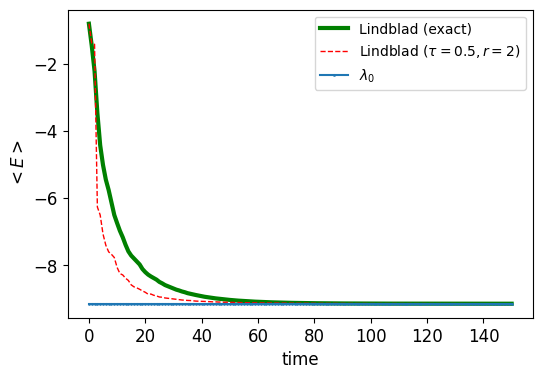

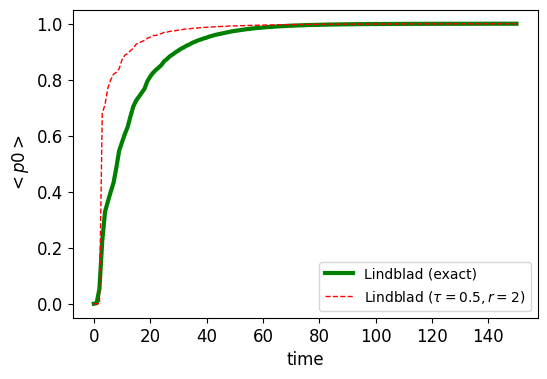

In [6]:

plt.figure(figsize=(6, 4))
plt.plot(
    times, avg_energy_e, "g-", label="Lindblad (exact)", linewidth=3, markersize=10
)
plt.plot(
    times_l,
    avg_energy_l,
    "r--",
    label=r"Lindblad $(\tau=0.5,r=2)$",
    linewidth=1,
    markersize=1,
)
plt.plot(
    times,
    np.ones_like(times) * E_GS,
    "p-",
    label=r"$\lambda_0$",
    linewidth=1.5,
    markersize=1,
)
plt.legend()
plt.xlabel("time", fontsize=12)
plt.ylabel(r"$<E>$", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=10)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(times, avg_pGS_e, "g-", label=r"Lindblad (exact)", linewidth=3, markersize=20)
plt.plot(
    times_l,
    avg_pGS_l,
    "r--",
    label=r"Lindblad $(\tau=0.5,r=2)$",
    linewidth=1,
    markersize=5,
)
plt.legend()
plt.xlabel("time", fontsize=12)
plt.ylabel(r"$<p0>$", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=10, loc="lower right")
plt.show()




Final fidelity with ground state: 0.9934617616012407


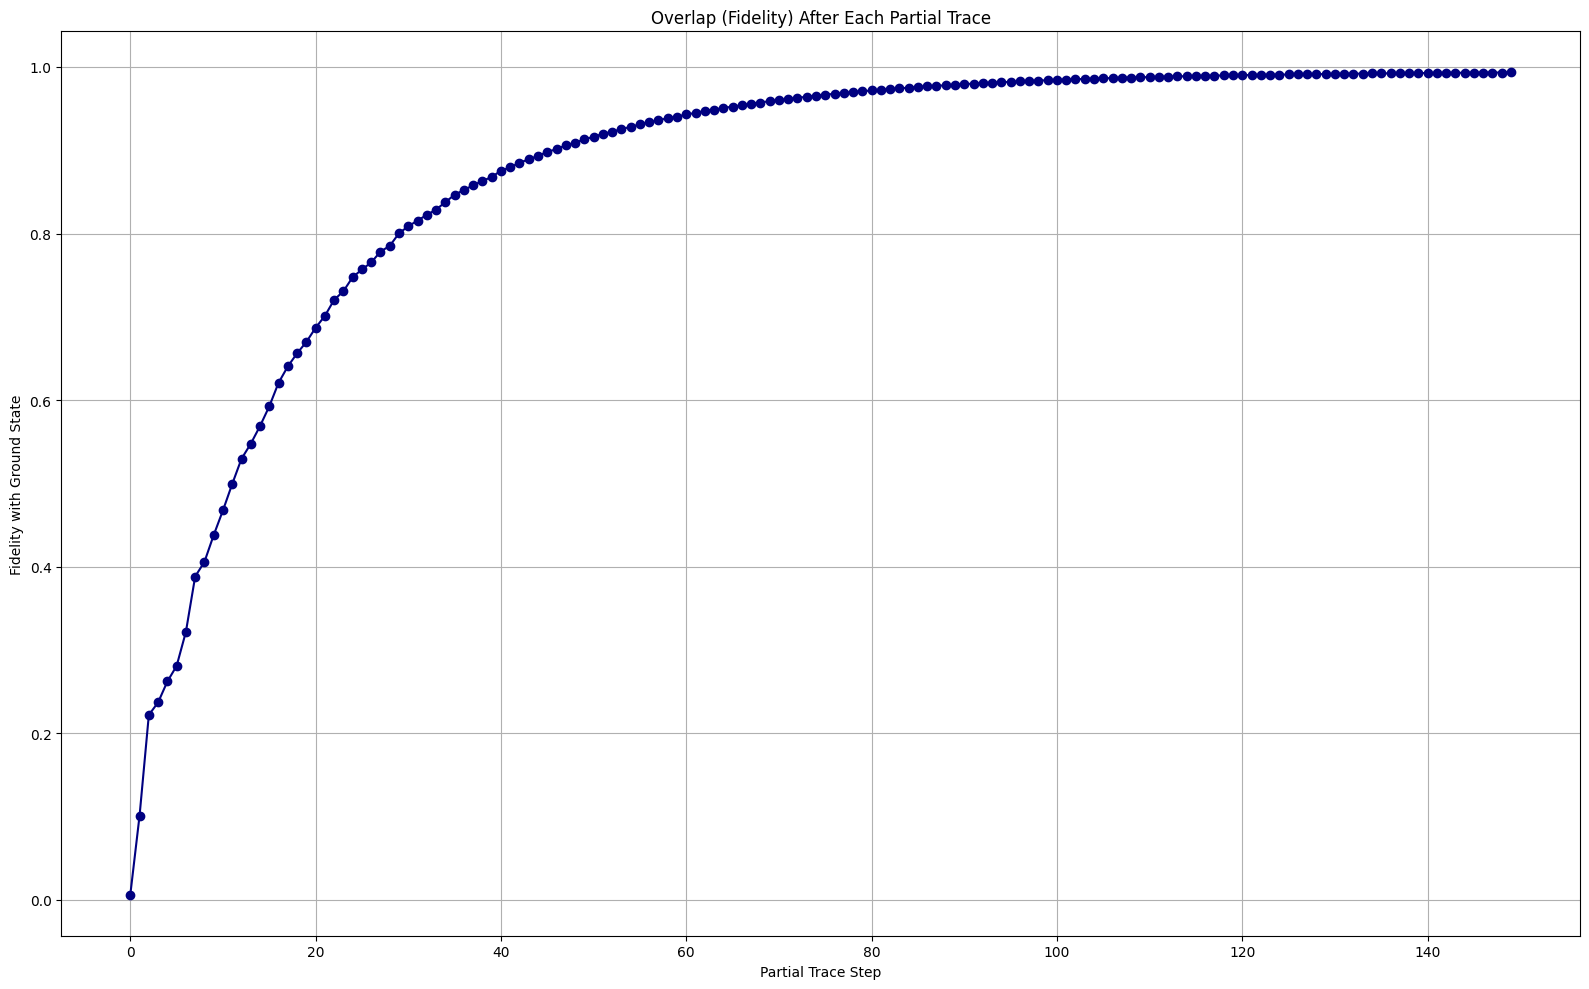

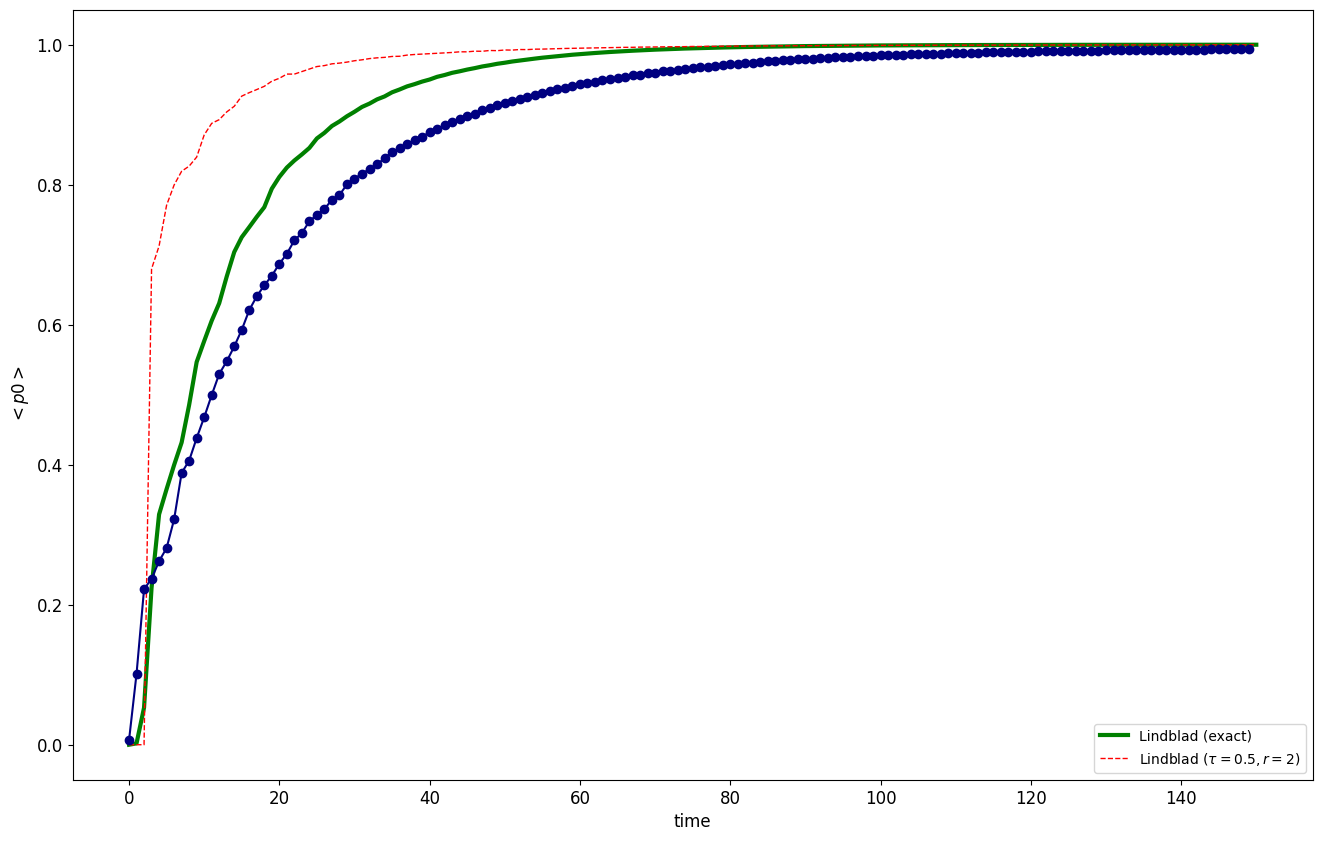

In [7]:
import numpy as np
import numpy as np
from functools import reduce
import matplotlib.pyplot as plt
import sys
import os

sys.path.insert(0, os.path.abspath("./.."))


from extract_unitaries import (
    Unitary,
    generate_qiskit_circuit_from_unitary,
    transpile_qiskit,
    compile_circuit,
    save_qiskit_as_qasm,
    calculate_approximation_error,
    reverse_qubit_order,
    phase_corrected_frobenius_norm,
    generate_qiskit_circuit_from_unitary_with_swaps
)

basis_gates = [
    "rx",
    "rz",
    "cz",
    "swap",
]

unitary_path = generate_path.generate_all_pickled_K(str(data_collection_path))
psi_0_path = generate_path.generate_psi_0_path(str(data_collection_path))
psi_GS_path = generate_path.generate_psi_GS_path(str(data_collection_path))

dilated_unitaries = np.load(unitary_path, allow_pickle=True)
psi_0 = np.load(psi_0_path, allow_pickle=True) + 0j
psi_GS = np.load(psi_GS_path, allow_pickle=True) + 0j

# psi_0 = np.zeros_like(psi_0, dtype=complex)
# psi_0[0] = 1.0


def partial_trace(rho, dimA, dimB):
    rho = rho.reshape((dimA, dimB, dimA, dimB))
    rhoA = np.trace(rho, axis1=1, axis2=3)
    rhoB = np.trace(rho, axis1=0, axis2=2)
    return rhoA, rhoB


def fresh_ancilla_rho(rho):
    ancilla = np.array([[1], [0]], dtype=complex) @ np.array([[1, 0]], dtype=complex)
    return np.kron(ancilla, rho)


overlaps = []
# overlaps.append(np.abs(np.vdot(psi_GS, psi_0)))
# Initialize state
n_qubits = int(np.log2(dilated_unitaries[0].shape[0]))
# rho = np.array([[1, 0], [0, 0]], dtype=complex)
# for _ in range(n_qubits - 1):
#     rho = np.kron(rho, np.array([[1, 0], [0, 0]], dtype=complex))  # |00...0><00...0|
rho = np.outer(psi_0, psi_0.conj()) + 0j
rho = np.kron(np.array([[1, 0], [0, 0]]), rho)  # |00...0><00...0|
# Apply in reverse order


counter = 0
for mat in dilated_unitaries:
    # Evolve: ρ → U ρ U†
    rho = mat @ rho @ mat.conj().T

    # After every 2 steps, do partial trace + re-add ancilla
    if counter % 2 == 0 and counter > 0:
        dim = int(rho.shape[0])

        dimA, dimB = 2, dim // 2  # Assume first qubit has dim 2
        rhoA, rhoB = partial_trace(rho, dimA, dimB)
        fidelity = np.real(psi_GS.conj().T @ rhoB @ psi_GS)
        overlaps.append(fidelity)
        rho = fresh_ancilla_rho(rhoB)  # Reinsert ancilla as |0><0| ⊗ rhoB

        # Fidelity computation

    counter += 1

# Final state
final_rho = rho

print(f"Final fidelity with ground state: {overlaps[-1]}")
plt.figure(figsize=(16, 10))
plt.plot(overlaps, marker="o", linestyle="-", color="navy")
plt.xlabel("Partial Trace Step")
plt.ylabel("Fidelity with Ground State")
plt.title("Overlap (Fidelity) After Each Partial Trace")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    f"{data_collection_path}/fidelity_plot.png", dpi=150
)  # Optional: save the figure

plt.show()

plt.figure(figsize=(16, 10))
plt.plot(times, avg_pGS_e, "g-", label=r"Lindblad (exact)", linewidth=3, markersize=20)
plt.plot(
    times_l,
    avg_pGS_l,
    "r--",
    label=r"Lindblad $(\tau=0.5,r=2)$",
    linewidth=1,
    markersize=5,
)
plt.plot(overlaps, marker="o", linestyle="-", color="navy")
plt.legend()
plt.xlabel("time", fontsize=12)
plt.ylabel(r"$<p0>$", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=10, loc="lower right")
plt.show()

In [8]:
len(dilated_unitaries)

301

## Transpile circuit without ancilla reset mechanism

In [9]:
unitary_path = generate_path.generate_all_pickled_K(str(data_collection_path))

qasm_path = generate_path.generate_qasm_path(str(data_collection_path))
bqskit_output_path = generate_path.generate_bqskit_output_path(
    str(data_collection_path)
)
qasm_generated = False
print(f"Processing {unitary_path}")
U = Unitary(unitary_path)

circuit = generate_qiskit_circuit_from_unitary(U)
circuit = transpile_qiskit(circuit, basis_gates)
if not qasm_generated:
    save_qiskit_as_qasm(circuit, qasm_path)
circuit, compiled_circuit = compile_circuit(
    qasm_path, bqskit_output_path, verbose=True
)
original_U = circuit.get_unitary().numpy
compiled_U = (compiled_circuit.get_unitary()).numpy

# Sometimes there is a global phase -1 on the synthesised unitary. Check if that is the case
approx_error = calculate_approximation_error(
    original_U, compiled_U, phase_corrected_frobenius_norm
)
original_U_bqskit_corrected = reverse_qubit_order(original_U)
compiled_U_bqskit_corrected = reverse_qubit_order(compiled_U)

approx_error_compiled = calculate_approximation_error(
    U.U, compiled_U_bqskit_corrected, phase_corrected_frobenius_norm
)

approx_error_original = calculate_approximation_error(
    original_U_bqskit_corrected, U.U, phase_corrected_frobenius_norm
)
print(f"Synthesis approximation error: {approx_error}")
print(f"Original approximation error: {approx_error_original}")
print(f"Compiled approximation error: {approx_error_compiled}")

Processing /Users/di75bus/Desktop/Repos/PhD/groundstate-preparation-via-lindbladians/data/experiments/4-1.0-2.2/dilated_unitaries.pickle
Function 'generate_qiskit_circuit_from_unitary' executed in 0.0016 seconds.
Function 'transpile_qiskit' executed in 0.1690 seconds.
Qiskit qasm output saved to: /Users/di75bus/Desktop/Repos/PhD/groundstate-preparation-via-lindbladians/data/experiments/4-1.0-2.2/output_original_circuit.qasm
-----------------------------------
Gate counts from the input circuit
RXGate Count: 646
RZGate Count: 928
CZGate Count: 444
-----------------------------------
-----------------------------------
Gate counts after BQSKit Synthesis
RXGate Count: 1309
RZGate Count: 1922
CZGate Count: 376
-----------------------------------
Function 'compile_circuit' executed in 19.3160 seconds.
Synthesis approximation error: 5.9147515986256876e-08
Original approximation error: 7.118709538723306e-12
Compiled approximation error: 5.9147806313827135e-08


## Transpile with fresh ancila mechanism

In [9]:
unitary_path = generate_path.generate_all_pickled_K(str(data_collection_path))

qasm_path = generate_path.generate_qasm_path(str(data_collection_path))
bqskit_output_path = generate_path.generate_bqskit_output_path(
    str(data_collection_path)
)
qasm_generated = False
print(f"Processing {unitary_path}")
U = Unitary(unitary_path)

circuit = generate_qiskit_circuit_from_unitary_with_swaps(U, T)
print(circuit.active_qudits)
input("Press Enter to continue...")
circuit = transpile_qiskit(circuit, basis_gates)
if not qasm_generated:
    save_qiskit_as_qasm(circuit, qasm_path)
circuit, compiled_circuit = compile_circuit(qasm_path, bqskit_output_path, verbose=True)
original_U = circuit.get_unitary().numpy
compiled_U = (compiled_circuit.get_unitary()).numpy

# Sometimes there is a global phase -1 on the synthesised unitary. Check if that is the case
approx_error = calculate_approximation_error(
    original_U, compiled_U, phase_corrected_frobenius_norm
)
original_U_bqskit_corrected = reverse_qubit_order(original_U)
compiled_U_bqskit_corrected = reverse_qubit_order(compiled_U)

approx_error_compiled = calculate_approximation_error(
    U.U, compiled_U_bqskit_corrected, phase_corrected_frobenius_norm
)

approx_error_original = calculate_approximation_error(
    original_U_bqskit_corrected, U.U, phase_corrected_frobenius_norm
)
print(f"Synthesis approximation error: {approx_error}")
print(f"Original approximation error: {approx_error_original}")
print(f"Compiled approximation error: {approx_error_compiled}")

Processing /Users/di75bus/Desktop/Repos/PhD/groundstate-preparation-via-lindbladians/data/experiments/4-1.0-2.2/dilated_unitaries.pickle


CircuitError: 'The amount of qubit(155)/clbit(0) arguments does not match the gate expectation (5).'

In [ ]:
# ancillas added always in state |0> to the left
m = np.eye(32)
mm = m @ np.kron(
    psi_0,
    np.array([1, 0]),
)
m = mm.reshape(-1, 1) @ mm.reshape(-1, 1).conj().T
idx = 0
for d in dilated_unitaries:
    m = d @ m
    if (idx % 2) == 0 and idx > 0:
        mm = partial_trace(m, 2, dim // 2)[1]
        m = np.kron(np.array([[1, 0], [0, 0]]), mm)
        
    idx += 1

np.abs(psi_GS.conj().T @ mm @ psi_GS)

np.float64(0.006561280733743733)

In [17]:
resulting_psi = compiled_U_bqskit_corrected @ np.kron(
    psi_0,
    np.array([1, 0]),
)
resulting_rho = resulting_psi.reshape(-1, 1) @ resulting_psi.reshape(-1, 1).conj().T
reduced_resulting_psi = partial_trace(resulting_rho, 2, dim // 2)[1]
psi_GS.conj().T @ reduced_resulting_psi @ psi_GS

np.complex128(0.022744512010095475+3.469446951953614e-18j)

Circuit(5)
	[RZGate([-3.1228966655203965])@(0,), RZGate([-3.141592653502216])@(1,), RZGate([3.141592653573122])@(2,), RZGate([3.1415926535622596])@(3,), RZGate([1.5950943242312379])@(4,)]
	[RXGate([0.4122402207803674])@(0,), RXGate([0.2959206598534704])@(1,), RXGate([1.5707963267948966])@(2,), RXGate([1.5707963267948966])@(3,), RXGate([1.5707963267948966])@(4,)]
	[RZGate([-1.3473139791546491])@(0,), RZGate([-1.4696906270507943])@(1,), RZGate([1.5707963267948966])@(2,), RZGate([1.5707963267948966])@(3,), RZGate([1.5707963267948966])@(4,)]
	[CZGate@(0, 1), CZGate@(0, 1), None, None, None]
	[RXGate([2.9030345100123327])@(0,), RZGate([3.0404869537736303])@(1,), None, None, None]
	[RZGate([1.5707963267948966])@(0,), RXGate([0.7010370930156049])@(1,), None, None, None]
	[None, RZGate([1.6719020266110611])@(1,), None, None, None]
	[CZGate@(0, 1), CZGate@(0, 1), None, None, None]
	[RZGate([0.2105338769798406])@(0,), RZGate([3.0404869534187178])@(1,), None, None, None]
	[RXGate([1.4190288192568